In [3]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Load & Verify Dataset
df = pd.read_csv('shopping_table.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (3900, 19)

First 5 rows:


,Customer_ID,Age,Gender,Item_Purchased,Category,Purchase_Amount_USD,Location,Size,Color,Season,Review_Rating,Subscription_Status,Payment_Method,Shipping_Type,Discount_Applied,Promo_Code_Used,Previous_Purchases,Preferred_Payment_Method,Frequency_of_Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [5]:
# Data Exploration
print("Basic Info")
print(df.info())
print("\n Statistical Summary ")
df.describe()

Basic Info
<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   str    
 3   Item_Purchased            3900 non-null   str    
 4   Category                  3900 non-null   str    
 5   Purchase_Amount_USD       3900 non-null   int64  
 6   Location                  3900 non-null   str    
 7   Size                      3900 non-null   str    
 8   Color                     3900 non-null   str    
 9   Season                    3900 non-null   str    
 10  Review_Rating             3900 non-null   float64
 11  Subscription_Status       3900 non-null   str    
 12  Payment_Method            3900 non-null   str    
 13  Shipping_Type             3900 non-null   str    
 14  Discount

,Customer_ID,Age,Purchase_Amount_USD,Review_Rating,Previous_Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [6]:
# Data Cleaning
# Check missing values
print("Missing Values")
print(df.isnull().sum())

# Check duplicates
print("\n Duplicate Rows")
print("Duplicates found:", df.duplicated().sum())

# Remove duplicates if any
df = df.drop_duplicates()
df = df.reset_index(drop=True)

# Check data types
print("\n Data Types")
print(df.dtypes)

print("\n Shape after Cleaning")
print(df.shape)

Missing Values
Customer_ID                 0
Age                         0
Gender                      0
Item_Purchased              0
Category                    0
Purchase_Amount_USD         0
Location                    0
Size                        0
Color                       0
Season                      0
Review_Rating               0
Subscription_Status         0
Payment_Method              0
Shipping_Type               0
Discount_Applied            0
Promo_Code_Used             0
Previous_Purchases          0
Preferred_Payment_Method    0
Frequency_of_Purchases      0
dtype: int64

 Duplicate Rows
Duplicates found: 0

 Data Types
Customer_ID                   int64
Age                           int64
Gender                          str
Item_Purchased                  str
Category                        str
Purchase_Amount_USD           int64
Location                        str
Size                            str
Color                           str
Season                      

In [7]:
# Feature Engineering (Create Age_Group)
# Create Age_Group from Age column
def age_group(age):
    if age < 20:
        return 'Teens'
    elif age < 30:
        return '20s'
    elif age < 40:
        return '30s'
    elif age < 50:
        return '40s'
    elif age < 60:
        return '50s'
    else:
        return '60s+'

df['Age_Group'] = df['Age'].apply(age_group)

# Verify
print(df['Age_Group'].value_counts())
print()
print(df[['Customer_ID', 'Age', 'Age_Group']].head(10))

Age_Group
60s+     788
50s      771
40s      739
20s      728
30s      724
Teens    150
Name: count, dtype: int64

   Customer_ID  Age Age_Group
0            1   55       50s
1            2   19     Teens
2            3   50       50s
3            4   21       20s
4            5   45       40s
5            6   46       40s
6            7   63      60s+
7            8   27       20s
8            9   26       20s
9           10   57       50s


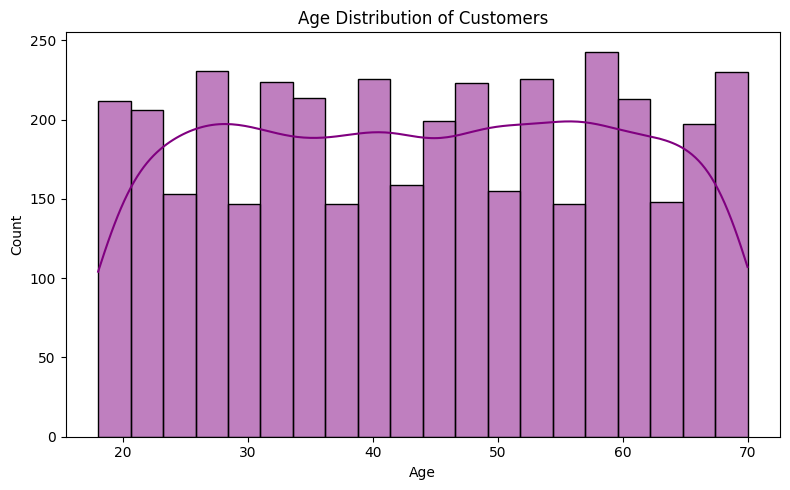

In [8]:
# EDA & Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, color='purple', kde=True)
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

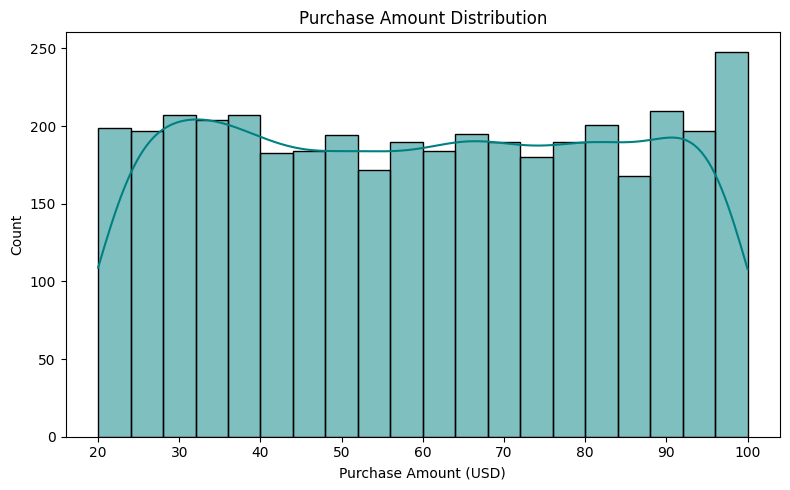

In [9]:
# 2) Purchase Amount Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Purchase_Amount_USD'], bins=20, color='teal', kde=True)
plt.title('Purchase Amount Distribution')
plt.xlabel('Purchase Amount (USD)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

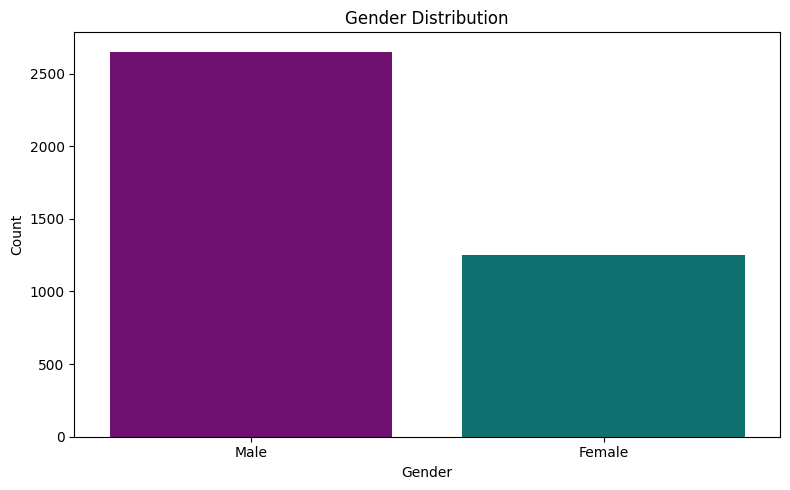

In [10]:
# 3) Gender Distribution
plt.figure(figsize=(8,5))
sns.countplot(x='Gender', data=df, palette=['purple', 'teal'])
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

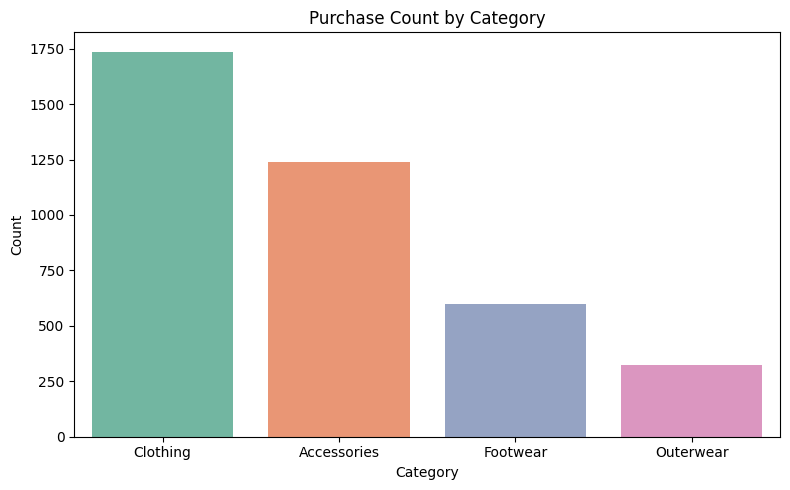

In [11]:
# 4)  Category wise Purchase
plt.figure(figsize=(8,5))
sns.countplot(x='Category', data=df, palette='Set2',
              order=df['Category'].value_counts().index)
plt.title('Purchase Count by Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

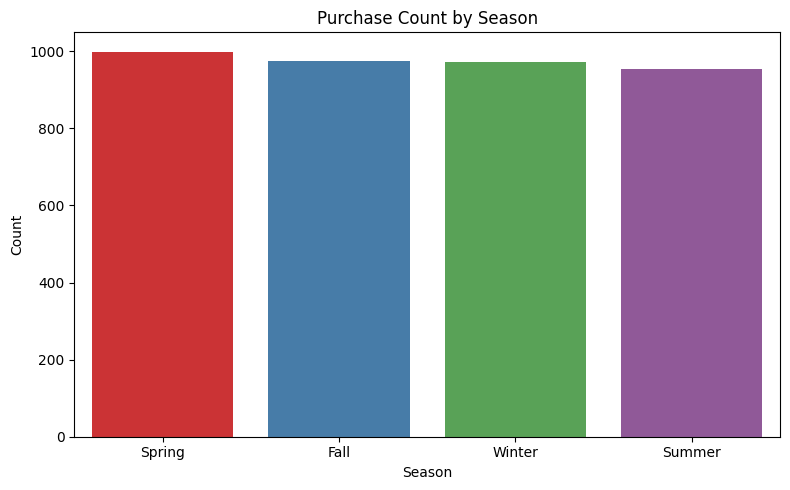

In [12]:
# 5)  Season wise Purchase
plt.figure(figsize=(8,5))
sns.countplot(x='Season', data=df, palette='Set1',
              order=df['Season'].value_counts().index)
plt.title('Purchase Count by Season')
plt.xlabel('Season')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

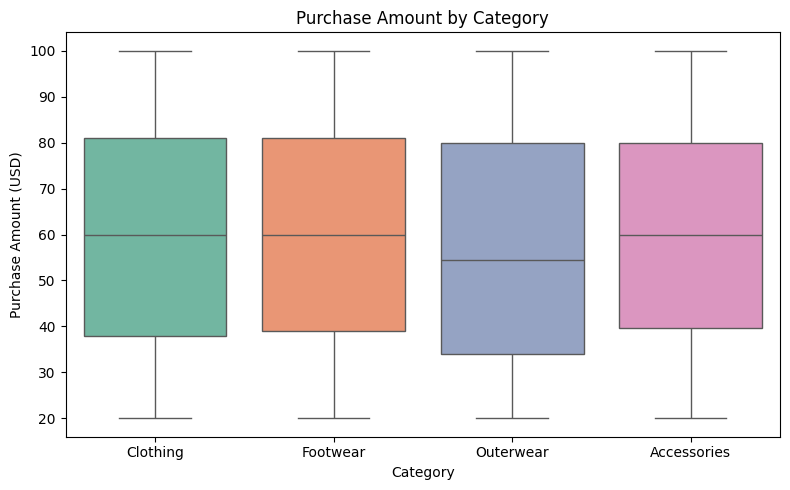

In [13]:
# 6)  Purchase Amount by Category
plt.figure(figsize=(8,5))
sns.boxplot(x='Category', y='Purchase_Amount_USD', data=df, palette='Set2')
plt.title('Purchase Amount by Category')
plt.xlabel('Category')
plt.ylabel('Purchase Amount (USD)')
plt.tight_layout()
plt.show()

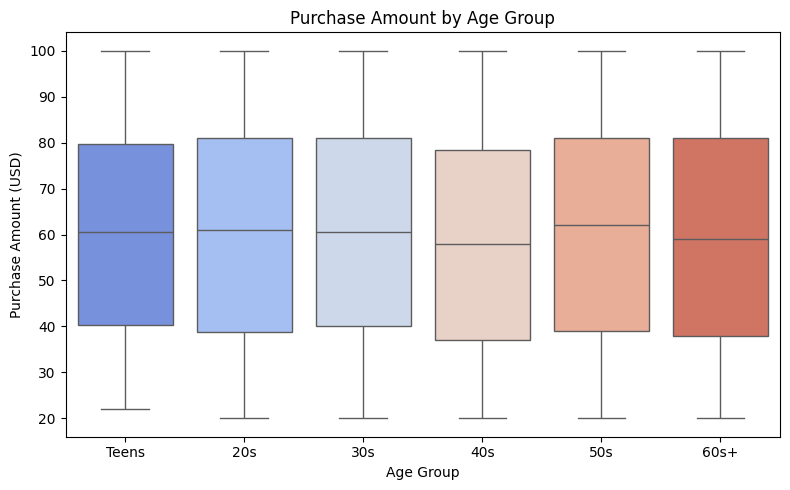

In [14]:
#7) Age Group vs Purchase Amount
plt.figure(figsize=(8,5))
sns.boxplot(x='Age_Group', y='Purchase_Amount_USD', data=df, palette='coolwarm',
            order=['Teens', '20s', '30s', '40s', '50s', '60s+'])
plt.title('Purchase Amount by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Purchase Amount (USD)')
plt.tight_layout()
plt.show()

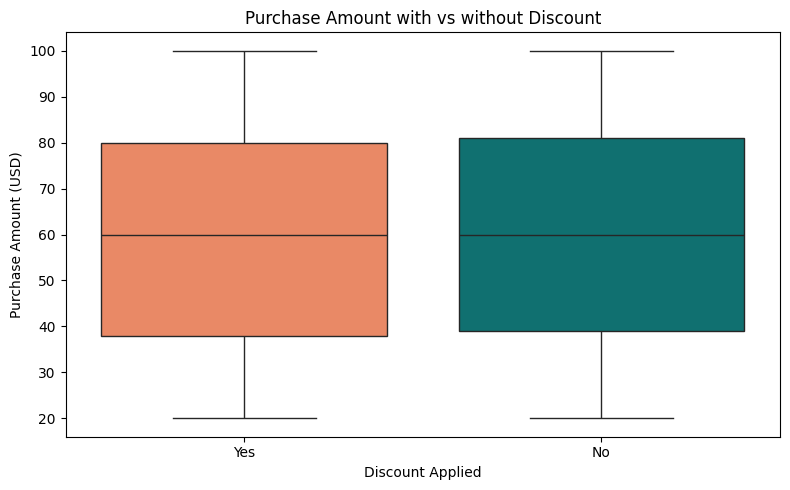

In [15]:
# 8) Discount Applied vs Purchase Amount
plt.figure(figsize=(8,5))
sns.boxplot(x='Discount_Applied', y='Purchase_Amount_USD', data=df, palette=['coral', 'teal'])
plt.title('Purchase Amount with vs without Discount')
plt.xlabel('Discount Applied')
plt.ylabel('Purchase Amount (USD)')
plt.tight_layout()
plt.show()

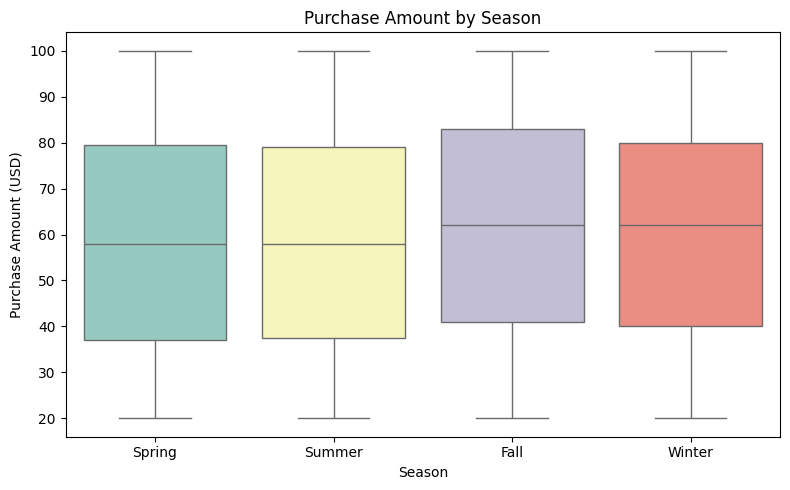

In [16]:
# 9)  Season vs Purchase Amount
plt.figure(figsize=(8,5))
sns.boxplot(x='Season', y='Purchase_Amount_USD', data=df, palette='Set3',
            order=['Spring', 'Summer', 'Fall', 'Winter'])
plt.title('Purchase Amount by Season')
plt.xlabel('Season')
plt.ylabel('Purchase Amount (USD)')
plt.tight_layout()
plt.show()

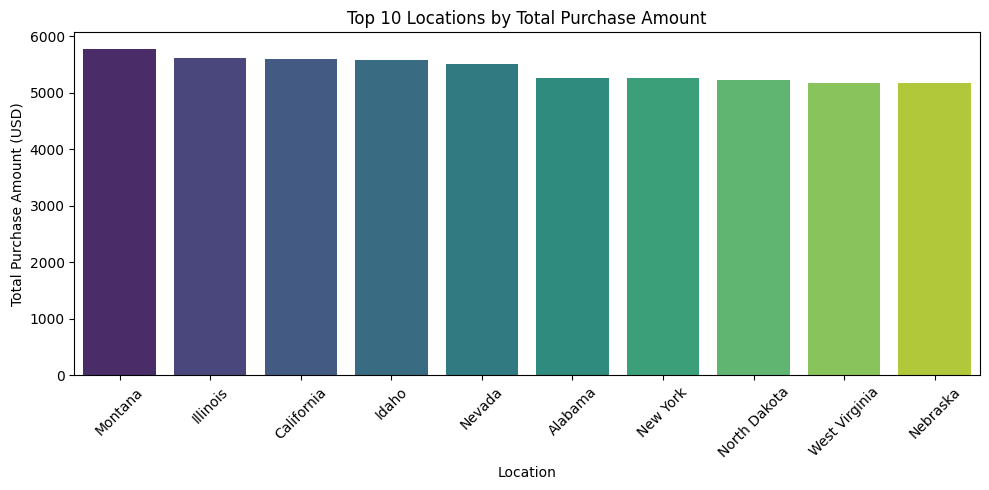

In [17]:
# 10)  Top 10 Locations by Purchase
plt.figure(figsize=(10,5))
top_locations = df.groupby('Location')['Purchase_Amount_USD'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_locations.index, y=top_locations.values, palette='viridis')
plt.title('Top 10 Locations by Total Purchase Amount')
plt.xlabel('Location')
plt.ylabel('Total Purchase Amount (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
# Preprocessing for Clustering
from sklearn.preprocessing import StandardScaler, LabelEncoder
# Select features for clustering
cluster_features = ['Age', 'Purchase_Amount_USD', 'Previous_Purchases', 
                    'Review_Rating', 'Frequency_of_Purchases']

# Make a copy
df_cluster = df[cluster_features].copy()

# Encode Frequency_of_Purchases (text → number)
le = LabelEncoder()
df_cluster['Frequency_of_Purchases'] = le.fit_transform(df['Frequency_of_Purchases'])

print("Frequency Encoding")
print(dict(zip(le.classes_, le.transform(le.classes_))))

# Scale all features
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cluster)

print("\nScaled Data Shape")
print(df_scaled.shape)

Frequency Encoding
{'Annually': np.int64(0), 'Bi-Weekly': np.int64(1), 'Every 3 Months': np.int64(2), 'Fortnightly': np.int64(3), 'Monthly': np.int64(4), 'Quarterly': np.int64(5), 'Weekly': np.int64(6)}

Scaled Data Shape
(3900, 5)


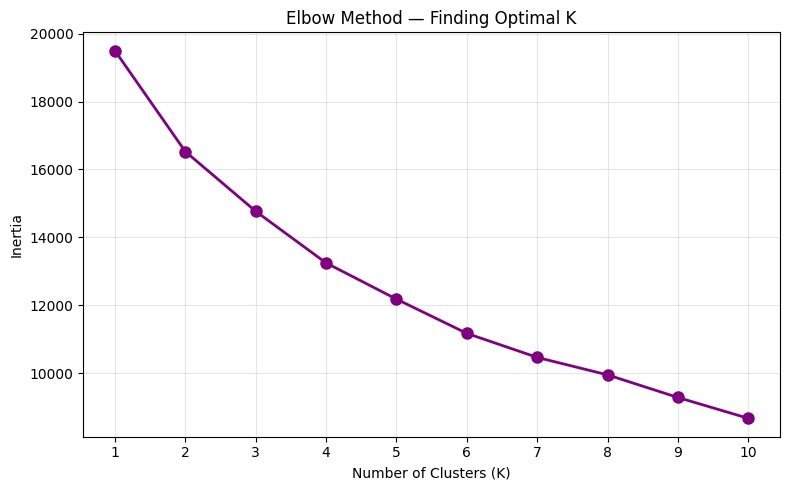

In [19]:
#  Elbow Method (Clustering)
from sklearn.cluster import KMeans

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o', color='purple', linewidth=2, markersize=8)
plt.title('Elbow Method — Finding Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
#  Build K-Means Model
# Build KMeans with K=4
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(df_scaled)

# Add cluster labels to original dataframe
df['Cluster'] = kmeans.labels_

print("Cluster Distribution")
print(df['Cluster'].value_counts().sort_index())

print("\nSilhouette Score")
from sklearn.metrics import silhouette_score
score = silhouette_score(df_scaled, kmeans.labels_)
print(f"Silhouette Score: {score:.4f}")

Cluster Distribution
Cluster
0     965
1     984
2    1009
3     942
Name: count, dtype: int64

Silhouette Score
Silhouette Score: 0.1459


In [22]:
# Cluster Profiling
# Profile each cluster
cluster_profile = df.groupby('Cluster').agg({
    'Age': 'mean',
    'Purchase_Amount_USD': 'mean',
    'Previous_Purchases': 'mean',
    'Review_Rating': 'mean',
    'Frequency_of_Purchases': lambda x: x.mode()[0],
    'Gender': lambda x: x.mode()[0],
    'Category': lambda x: x.mode()[0],
    'Season': lambda x: x.mode()[0],
    'Subscription_Status': lambda x: x.mode()[0]
}).round(2)

print("Cluster Profile")
print(cluster_profile)

Cluster Profile
           Age  Purchase_Amount_USD  Previous_Purchases  Review_Rating  \
Cluster                                                                  
0        56.67                81.71               26.01           3.94   
1        56.28                37.79               26.44           3.52   
2        31.98                59.76               11.24           3.74   
3        31.35                60.24               38.66           3.81   

        Frequency_of_Purchases Gender  Category  Season Subscription_Status  
Cluster                                                                      
0                    Bi-Weekly   Male  Clothing  Spring                  No  
1                       Weekly   Male  Clothing  Spring                  No  
2                    Bi-Weekly   Male  Clothing    Fall                  No  
3                    Quarterly   Male  Clothing  Winter                  No  


In [23]:
# Label Clusters in Dataframe
# Map cluster numbers to meaningful names
cluster_labels = {
    0: 'Premium Seniors',
    1: 'Budget Seniors',
    2: 'Young Occasionals',
    3: 'Young Loyals'
}

df['Customer_Segment'] = df['Cluster'].map(cluster_labels)

print("Segment Distribution")
print(df['Customer_Segment'].value_counts())

print()
print("Sample Data with Segments")
print(df[['Customer_ID', 'Age', 'Purchase_Amount_USD', 
          'Previous_Purchases', 'Customer_Segment']].head(10))

Segment Distribution
Customer_Segment
Young Occasionals    1009
Budget Seniors        984
Premium Seniors       965
Young Loyals          942
Name: count, dtype: int64

Sample Data with Segments
   Customer_ID  Age  Purchase_Amount_USD  Previous_Purchases  \
0            1   55                   53                  14   
1            2   19                   64                   2   
2            3   50                   73                  23   
3            4   21                   90                  49   
4            5   45                   49                  31   
5            6   46                   20                  14   
6            7   63                   85                  49   
7            8   27                   34                  19   
8            9   26                   97                   8   
9           10   57                   31                   4   

    Customer_Segment  
0     Budget Seniors  
1  Young Occasionals  
2    Premium Seniors  
3       

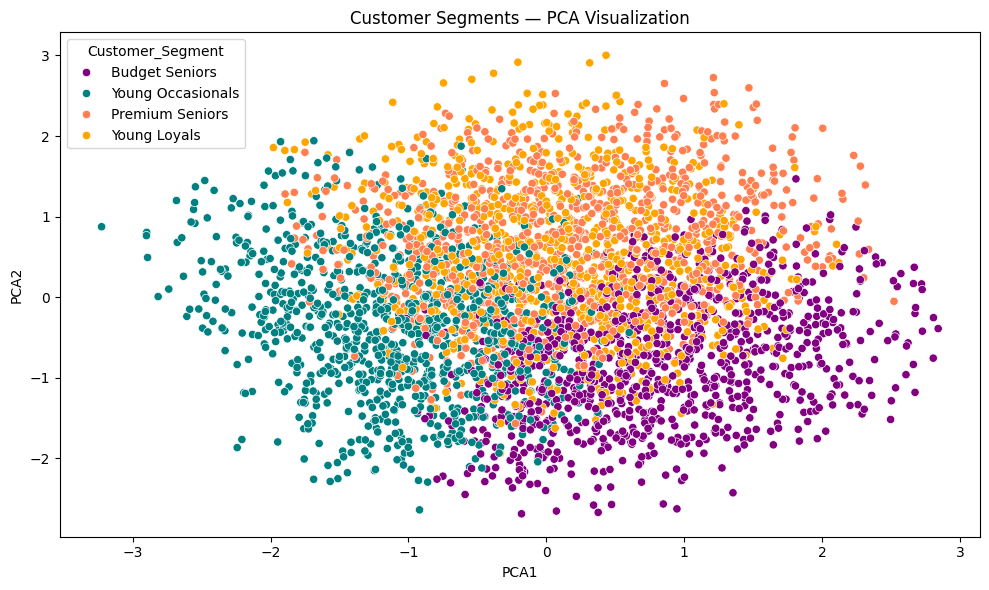

Variance Explained: 42.09%


In [24]:
# Visualize Clusters using PCA
from sklearn.decomposition import PCA

# Reduce to 2D
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

# Add to dataframe
df['PCA1'] = df_pca[:, 0]
df['PCA2'] = df_pca[:, 1]

# Plot
plt.figure(figsize=(10,6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Customer_Segment', 
                data=df, palette=['purple', 'teal', 'coral', 'orange'])
plt.title('Customer Segments — PCA Visualization')
plt.tight_layout()
plt.show()

print(f"Variance Explained: {pca.explained_variance_ratio_.sum()*100:.2f}%")

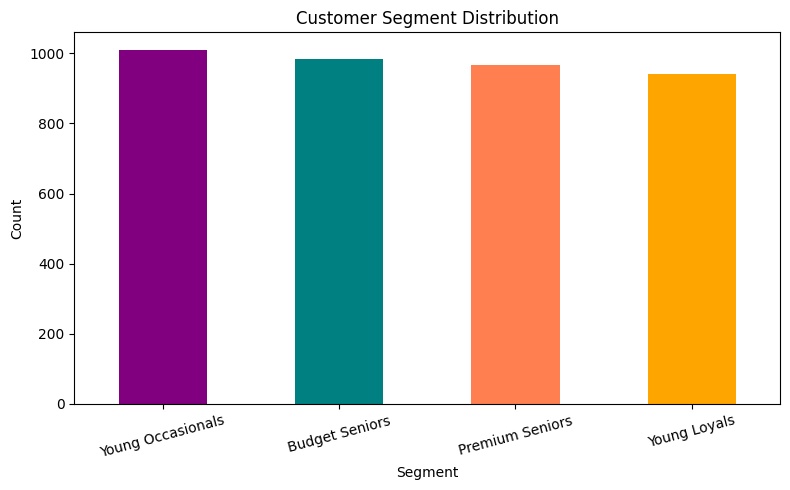

In [25]:
# Segment wise Visualizations
# 1)  Segment Distribution
plt.figure(figsize=(8,5))
df['Customer_Segment'].value_counts().plot(kind='bar', color=['purple','teal','coral','orange'])
plt.title('Customer Segment Distribution')
plt.xlabel('Segment')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

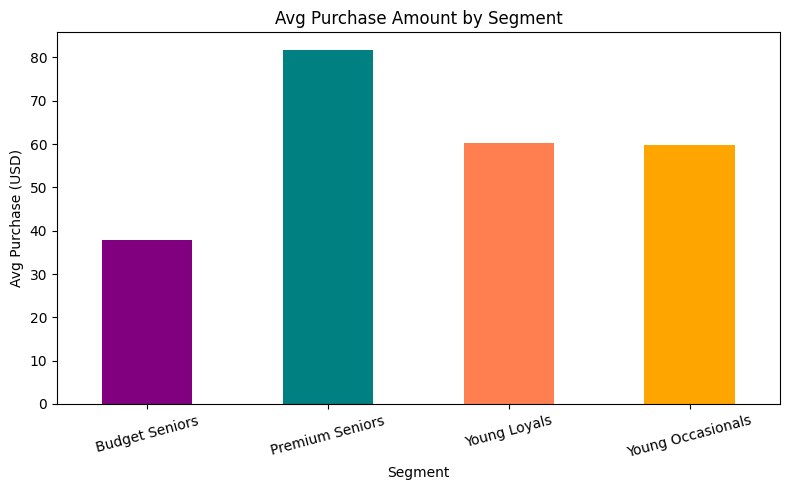

In [26]:
# 2) Avg Purchase by Segment
plt.figure(figsize=(8,5))
df.groupby('Customer_Segment')['Purchase_Amount_USD'].mean().plot(kind='bar', color=['purple','teal','coral','orange'])
plt.title('Avg Purchase Amount by Segment')
plt.xlabel('Segment')
plt.ylabel('Avg Purchase (USD)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

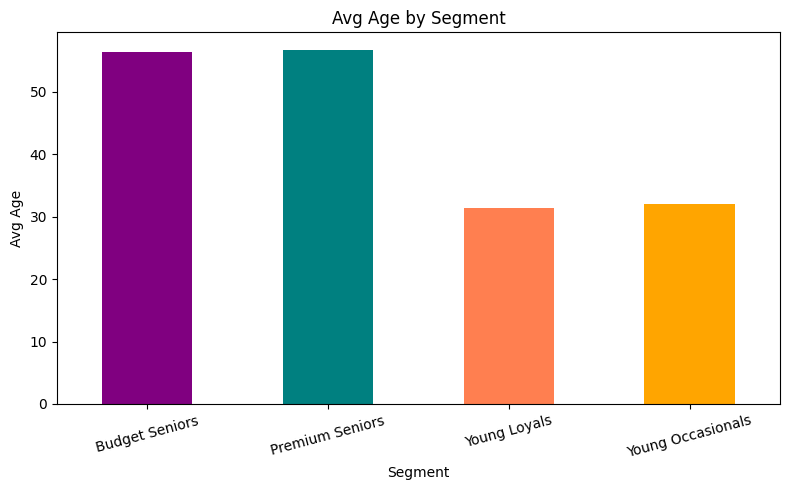

In [27]:
# 3) Avg Age by Segment
plt.figure(figsize=(8,5))
df.groupby('Customer_Segment')['Age'].mean().plot(kind='bar', color=['purple','teal','coral','orange'])
plt.title('Avg Age by Segment')
plt.xlabel('Segment')
plt.ylabel('Avg Age')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [29]:
# Export final dataframe 
df.to_csv('customer_segments.csv', index=False)

In [30]:
# Final Summary

print("-----CUSTOMER SEGMENTATION ANALYSIS SUMMARY-----")

print(f"\n Dataset        : Shopping Trends")
print(f" Total Customers : {len(df)}")
print(f" Features Used   : Age, Purchase Amount, Previous Purchases, Review Rating, Frequency")
print(f" Algorithm       : K-Means Clustering")
print(f" Optimal K       : 4 Clusters (Elbow Method)")
print(f" Silhouette Score: 0.1459")

print("\n--- Cluster Summary ---")
summary = df.groupby('Customer_Segment').agg({
    'Age': 'mean',
    'Purchase_Amount_USD': 'mean',
    'Previous_Purchases': 'mean',
    'Review_Rating': 'mean'
}).round(2)
print(summary)

print("\n--- Segment Size ---")
print(df['Customer_Segment'].value_counts())

print("\n--- Key Findings ---")
print(" Premium Seniors  → Highest spenders ($81.71 avg)")
print(" Young Loyals     → Most loyal (38.66 avg purchases)")
print(" Budget Seniors   → Lowest spenders ($37.79 avg)")
print(" Young Occasionals→ Least loyal (11.24 avg purchases)")

print("\n--- Tools Used ---")
print(" SQL      → Data extraction from MySQL")
print(" Python   → Clustering & EDA")
print(" Excel    → Pivot table summary")
print(" Power BI → Interactive dashboard")

-----CUSTOMER SEGMENTATION ANALYSIS SUMMARY-----

 Dataset        : Shopping Trends
 Total Customers : 3900
 Features Used   : Age, Purchase Amount, Previous Purchases, Review Rating, Frequency
 Algorithm       : K-Means Clustering
 Optimal K       : 4 Clusters (Elbow Method)
 Silhouette Score: 0.1459

--- Cluster Summary ---
                     Age  Purchase_Amount_USD  Previous_Purchases  \
Customer_Segment                                                    
Budget Seniors     56.28                37.79               26.44   
Premium Seniors    56.67                81.71               26.01   
Young Loyals       31.35                60.24               38.66   
Young Occasionals  31.98                59.76               11.24   

                   Review_Rating  
Customer_Segment                  
Budget Seniors              3.52  
Premium Seniors             3.94  
Young Loyals                3.81  
Young Occasionals           3.74  

--- Segment Size ---
Customer_Segment
Young Oc

In [31]:
pd.read_csv('customer_segments.csv').to_excel('customer_segments.xlsx', index=False)